In [1]:
# Automatically reload .py files when they are changed
%load_ext autoreload
%autoreload 2

# Numerical packages
import numpy as np
from scipy import optimize

# Plotting
import matplotlib.pyplot as plt

plt.rcParams.update({
    'axes.grid': True,
    'grid.color': 'black',
    'grid.alpha': 0.25,
    'grid.linestyle': '-'
})
plt.rcParams.update({'font.size': 14})

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Import the model classes
from Consumer import ConsumerClass
from Government import GovernmentClass

print("Everything is set up correctly!")

Everything is set up correctly!


# 1. A consumer with two nests

I consider a consumer who chooses between food, bus trips and train trips. Bus and train belong to a lower CES nest and are first combined into a travel composite. I then combine this travel composite with food in an upper CES nest.


## 1.1 The problem in nested budget shares

Instead of choosing quantities directly, I formulate the problem in nested budget shares. I let $s_1$ denote the share of income spent on food and $w$ denote the share of the remaining travel budget spent on bus trips.

The resulting budget shares are

$$
s_1,\qquad
s_2=(1-s_1)w,\qquad
s_3=(1-s_1)(1-w).
$$

I therefore always have

$$
s_1+s_2+s_3=1.
$$

This formulation ensures that the budget constraint is satisfied automatically. I can therefore solve the problem over the simple box $[0,1]\times[0,1]$.


## 1.2 Calibration

I consider two calibrations. I keep all parameters fixed except for the elasticity of substitution between bus and train, $\sigma_B$. In the complements calibration I set $\sigma_B=0.40$, while in the substitutes calibration I set $\sigma_B=3.00$.

In [8]:
# a. I create the complements calibration
model_complements = ConsumerClass()

# b. I create the substitutes calibration
model_substitutes = ConsumerClass(
    par={'sigma_B': 3.0}
)

# c. I print both calibrations to check the parameters
print(model_complements)

print('')

print(model_substitutes)

ConsumerClass
  alpha = 0.6000, beta = 0.5000
  sigma_A = 0.8000, sigma_B = 0.4000
  p1 = 1.0000, p2 = 1.0000, p3 = 1.5000
  I = 10.0000

ConsumerClass
  alpha = 0.6000, beta = 0.5000
  sigma_A = 0.8000, sigma_B = 3.0000
  p1 = 1.0000, p2 = 1.0000, p3 = 1.5000
  I = 10.0000


## 1.3 How do you know your answer is right?

### 1.3.1 Is the answer possible?

Since there is no closed-form solution for this model, I first check whether the numerical solution satisfies the basic requirements of the consumer problem. I check that all three budget shares are strictly between zero and one, that they sum to one, and that all three quantities are positive.

In [14]:
def check_solution(model,opt):
    """ Check whether a numerical solution satisfies the basic model requirements. """

    # a. I collect the three budget shares
    shares = np.array([
        opt.s1,
        opt.s2,
        opt.s3
    ])

    # b. I check that all budget shares are strictly between zero and one
    assert np.all(
        shares > 0.0
    ), 'at least one budget share is not positive'

    assert np.all(
        shares < 1.0
    ), 'at least one budget share is not below one'

    # c. I check that the three budget shares sum to one
    assert np.isclose(
        np.sum(shares),
        1.0
    ), 'budget shares do not sum to one'

    # d. I translate the optimal nested shares into quantities
    x1,x2,x3 = model.quantities(
        opt.s1,
        opt.w
    )

    quantities = np.array([
        x1,
        x2,
        x3
    ])

    # e. I check that all optimal quantities are positive
    assert np.all(
        quantities > 0.0
    ), 'at least one optimal quantity is not positive'

    return True

### 1.3.2 Do two different methods agree?

As a second check, I solve the same consumer problem using two different numerical methods: a two-dimensional grid search and L-BFGS-B. I compare the solutions in Section 2 after implementing both methods. If the two methods produce approximately the same optimal nested budget shares and utility, this provides additional evidence that the numerical solution is correct.

In [15]:
def check_methods_agree(model,N=1000,atol=0.002):
    """ Check whether grid search and L-BFGS-B give approximately the same solution. """

    # a. I solve the model using a fine grid search
    opt_grid = model.solve_grid(
        N=N,
        do_print=False
    )

    # b. I solve the same model using L-BFGS-B
    opt_lbfgsb = model.solve(
        do_print=False
    )

    # c. I collect the two nested budget shares from each method
    grid_solution = np.array([
        opt_grid.s1,
        opt_grid.w
    ])

    lbfgsb_solution = np.array([
        opt_lbfgsb.s1,
        opt_lbfgsb.w
    ])

    # d. I calculate the absolute difference between the two solutions
    difference = np.abs(
        grid_solution - lbfgsb_solution
    )

    # e. I check that the two numerical methods give approximately the same answer
    assert np.allclose(
        grid_solution,
        lbfgsb_solution,
        atol=atol
    ), 'grid search and L-BFGS-B do not give approximately the same solution'

    # f. I return the solutions so I can inspect the comparison
    return {
        'grid_s1': opt_grid.s1,
        'grid_w': opt_grid.w,
        'L-BFGS-B_s1': opt_lbfgsb.s1,
        'L-BFGS-B_w': opt_lbfgsb.w,
        'difference_s1': difference[0],
        'difference_w': difference[1]
    }

In [16]:
# a. I check the complements calibration
check_complements = check_methods_agree(
    model_complements
)

# b. I check the substitutes calibration
check_substitutes = check_methods_agree(
    model_substitutes
)

print('Complements:')
print(check_complements)

print('')

print('Substitutes:')
print(check_substitutes)

print('')
print('Both numerical checks passed')

Complements:
{'grid_s1': np.float64(0.5355355355355356), 'grid_w': np.float64(0.4394394394394394), 'L-BFGS-B_s1': np.float64(0.5356233806953101), 'L-BFGS-B_w': np.float64(0.43947902810370126), 'difference_s1': np.float64(8.784515977455776e-05), 'difference_w': np.float64(3.958866426184704e-05)}

Substitutes:
{'grid_s1': np.float64(0.5385385385385385), 'grid_w': np.float64(0.6926926926926927), 'L-BFGS-B_s1': np.float64(0.5382253431946789), 'L-BFGS-B_w': np.float64(0.6923077683280843), 'difference_s1': np.float64(0.0003131953438596513), 'difference_w': np.float64(0.00038492436460846324)}

Both numerical checks passed


The two numerical methods produce very similar solutions in both calibrations. In the complements calibration, the absolute differences between the grid-search and L-BFGS-B solutions are below $10^{-4}$ for both nested shares. In the substitutes calibration, the differences are still below $4\times10^{-4}$.

I therefore conclude that the two methods agree closely. This provides additional evidence that the numerical solutions are correct, even though the grid search is restricted to discrete grid points while L-BFGS-B searches over the continuous choice space.

# 2. Solving the model numerically


I solve the consumer problem numerically using two different methods. I first use a two-dimensional grid search and then L-BFGS-B. I use both methods for the complements and substitutes calibrations.

## 2.1 A two-dimensional grid search

### 2.1.1 Grid-search solution

I first solve the consumer problem by constructing a two-dimensional grid over the nested budget shares $s_1$ and $w$. I evaluate utility at every combination and select the point with the highest utility. I report the optimal nested shares $(s_1,w)$ and the implied budget shares $(s_1,s_2,s_3)$ for both calibrations.

In [17]:
import pandas as pd
import time


# a. I choose a fine grid for reporting the grid-search solution
N_report = 1000


# b. I solve the complements calibration using grid search
opt_grid_complements = model_complements.solve_grid(
    N=N_report,
    do_print=False
)


# c. I solve the substitutes calibration using the same grid
opt_grid_substitutes = model_substitutes.solve_grid(
    N=N_report,
    do_print=False
)


# d. I check that both numerical solutions satisfy the basic model requirements
check_solution(
    model_complements,
    opt_grid_complements
)

check_solution(
    model_substitutes,
    opt_grid_substitutes
)


# e. I collect the results in one table
grid_solution_table = pd.DataFrame([
    {
        'calibration': 'Complements',
        'N': N_report,
        's1': opt_grid_complements.s1,
        'w': opt_grid_complements.w,
        's2': opt_grid_complements.s2,
        's3': opt_grid_complements.s3,
        'utility': opt_grid_complements.u
    },
    {
        'calibration': 'Substitutes',
        'N': N_report,
        's1': opt_grid_substitutes.s1,
        'w': opt_grid_substitutes.w,
        's2': opt_grid_substitutes.s2,
        's3': opt_grid_substitutes.s3,
        'utility': opt_grid_substitutes.u
    }
])


# f. I display the grid-search solutions
grid_solution_table.round(6)

,calibration,N,s1,w,s2,s3,utility
0,Complements,1000,0.535536,0.439439,0.204104,0.26036,3.401680
1,Substitutes,1000,0.538539,0.692693,0.319651,0.14181,3.485104


I find an interior solution in both calibrations. The optimal food share $s_1$ is similar across the two calibrations, while the allocation of the travel budget differs substantially. In the complements calibration, the travel budget is split relatively evenly between bus and train. In the substitutes calibration, I allocate a much larger share of the travel budget to bus trips, which are cheaper than train trips.

### 2.1.2 Utility surface and contour plots

I visualize utility over the nested budget shares using both a three-dimensional surface plot and a contour plot. I mark the grid-search solution in each figure. I make the same plots for both calibrations so that I can compare the shape of the utility functions.

In [18]:
def plot_grid_solution(model,title,N=200):
    """ I plot the utility surface and contour plot for one calibration. """

    # a. I solve the model on a grid that is sufficiently fine for plotting
    opt_plot = model.solve_grid(
        N=N,
        do_print=False
    )

    # b. I create one figure with a 3D plot and a contour plot
    fig = plt.figure(
        figsize=(13,5)
    )


    # c. I create the three-dimensional utility surface
    ax = fig.add_subplot(
        1,
        2,
        1,
        projection='3d'
    )

    surface = ax.plot_surface(
        opt_plot.s1_grid,
        opt_plot.w_grid,
        opt_plot.u_grid,
        cmap='viridis',
        alpha=0.90
    )

    # d. I mark the grid-search optimum on the utility surface
    ax.scatter(
        opt_plot.s1,
        opt_plot.w,
        opt_plot.u,
        color='black',
        s=60,
        label='Grid-search optimum'
    )

    # e. I label the three-dimensional figure
    ax.set_xlabel(
        r'food budget share, $s_1$'
    )

    ax.set_ylabel(
        r'bus share of travel budget, $w$'
    )

    ax.set_zlabel(
        'utility'
    )

    ax.set_title(
        f'{title}: utility surface'
    )

    ax.legend()

    fig.colorbar(
        surface,
        ax=ax,
        shrink=0.65,
        pad=0.10,
        label='utility'
    )


    # f. I create the contour plot
    ax = fig.add_subplot(
        1,
        2,
        2
    )

    contour = ax.contourf(
        opt_plot.s1_grid,
        opt_plot.w_grid,
        opt_plot.u_grid,
        levels=30,
        cmap='viridis'
    )

    # g. I mark the same grid-search optimum on the contour plot
    ax.scatter(
        opt_plot.s1,
        opt_plot.w,
        color='black',
        s=60,
        label='Grid-search optimum'
    )

    # h. I label the contour plot
    ax.set_xlabel(
        r'food budget share, $s_1$'
    )

    ax.set_ylabel(
        r'bus share of travel budget, $w$'
    )

    ax.set_title(
        f'{title}: utility contours'
    )

    ax.legend()

    fig.colorbar(
        contour,
        ax=ax,
        label='utility'
    )

    # i. I adjust the spacing between the plots
    fig.tight_layout()

    return opt_plot

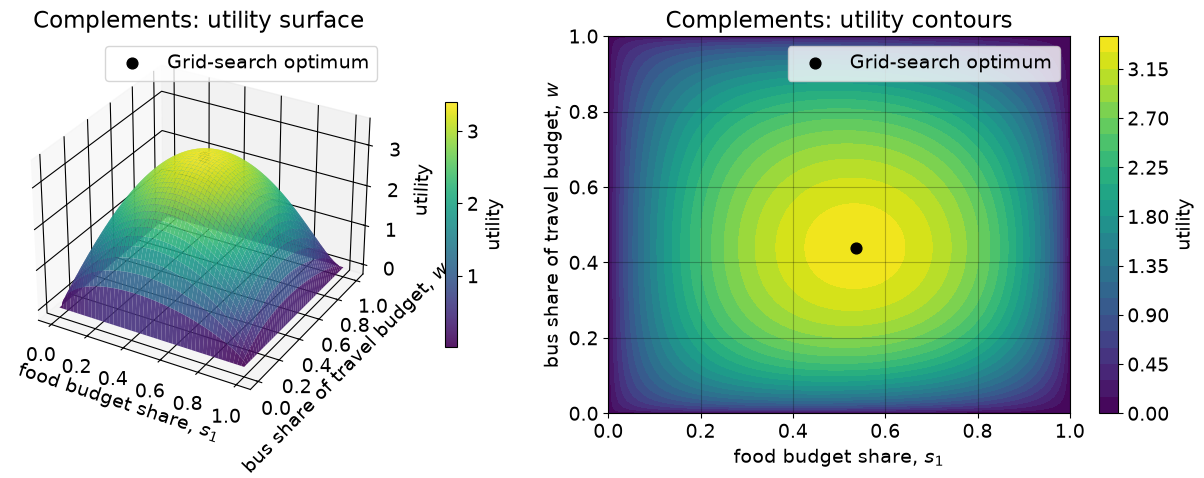

In [19]:
# I plot the utility surface for the complements calibration
plot_complements = plot_grid_solution(
    model_complements,
    title='Complements',
    N=200
)

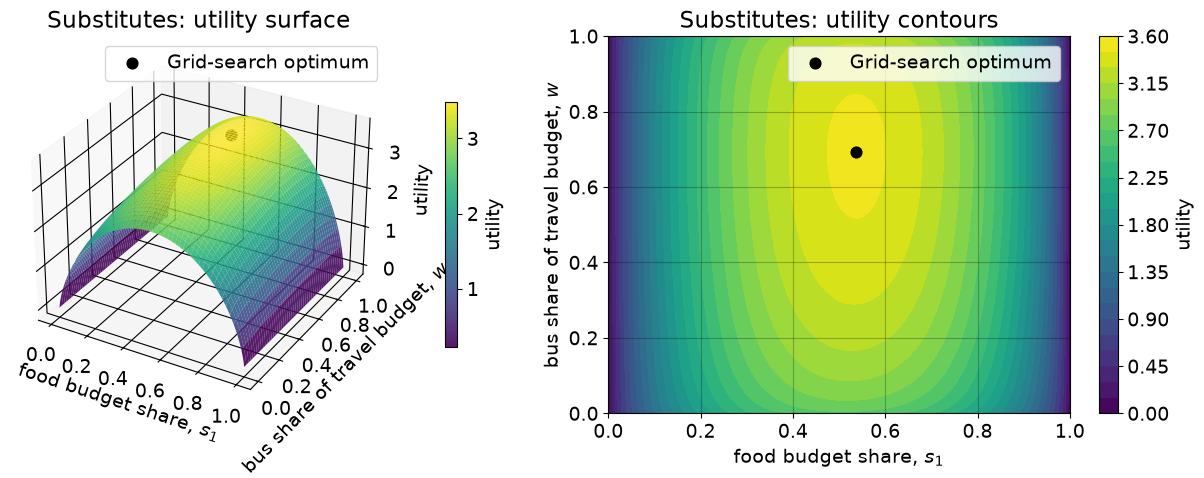

In [20]:
# I plot the utility surface for the substitutes calibration
plot_substitutes = plot_grid_solution(
    model_substitutes,
    title='Substitutes',
    N=200
)

### 2.1.3 Grid size and numerical accuracy

I now examine how the grid-search solution changes when I increase the number of grid points. I use $N=50$, $N=100$, $N=500$ and $N=1000$, as specified in the assignment.

I measure how much the solution moves by calculating the Euclidean distance between the nested shares $(s_1,w)$ obtained with the current grid and those obtained with the previous grid. I also report the number of utility evaluations. Since I evaluate $N$ values of each of the two choice variables, the total number of utility evaluations is $N^2$.

In [21]:
def compare_grid_sizes(model,N_values):
    """ I solve the model for several grid sizes and compare the solutions. """

    # a. I create an empty list in which I store the results
    results = []

    # b. I use this variable to remember the previous grid solution
    previous_solution = None


    # c. I solve the model for each grid size
    for N in N_values:

        # i. I solve the consumer problem using an N x N grid
        opt_grid = model.solve_grid(
            N=N,
            do_print=False
        )

        # ii. I check that the numerical solution is feasible
        check_solution(
            model,
            opt_grid
        )

        # iii. I calculate how much the solution moves relative
        # to the previous grid size
        if previous_solution is None:

            movement = np.nan

        else:

            movement = np.sqrt(
                (opt_grid.s1 - previous_solution[0])**2
                +
                (opt_grid.w - previous_solution[1])**2
            )

        # iv. I store the results from this grid size
        results.append({
            'N': N,
            's1': opt_grid.s1,
            'w': opt_grid.w,
            's2': opt_grid.s2,
            's3': opt_grid.s3,
            'utility': opt_grid.u,
            'movement_from_previous': movement,
            'function_evaluations': opt_grid.nfev
        })

        # v. I save the current solution so I can compare it
        # with the next, finer grid
        previous_solution = (
            opt_grid.s1,
            opt_grid.w
        )


    # d. I collect the results in a DataFrame
    return pd.DataFrame(
        results
    )


# e. I choose the grid sizes requested in the assignment
N_values = [
    50,
    100,
    500,
    1000
]


# f. I run the comparison for the complements calibration
grid_complements = compare_grid_sizes(
    model_complements,
    N_values
)


# g. I run the same comparison for the substitutes calibration
grid_substitutes = compare_grid_sizes(
    model_substitutes,
    N_values
)

In [22]:
# I display the results for the complements calibration
grid_complements.round(6)

,N,s1,w,s2,s3,utility,movement_from_previous,function_evaluations
0,50,0.530612,0.448980,0.210746,0.258642,3.400748,NaN,2500
1,100,0.535354,0.444444,0.206510,0.258137,3.401482,0.006561,10000
2,500,0.535070,0.438878,0.204047,0.260882,3.401674,0.005574,250000
3,1000,0.535536,0.439439,0.204104,0.260360,3.401680,0.000729,1000000


In [23]:
# I display the results for the substitutes calibration
grid_substitutes.round(6)

,N,s1,w,s2,s3,utility,movement_from_previous,function_evaluations
0,50,0.530612,0.693878,0.325698,0.143690,3.484594,NaN,2500
1,100,0.535354,0.696970,0.323845,0.140802,3.485005,0.005660,10000
2,500,0.539078,0.691383,0.318673,0.142248,3.485097,0.006715,250000
3,1000,0.538539,0.692693,0.319651,0.141810,3.485104,0.001417,1000000


The grid-search solution becomes increasingly stable as I increase the number of grid points, but the improvement is not completely smooth. For example, the movement in the substitutes calibration can be larger between two finer grids than between two coarser grids. This occurs because each grid contains a different discrete set of possible choices, so a finer grid does not necessarily contain the optimum from the previous grid.

The computational cost increases much more predictably. Since I search over two dimensions, the number of utility evaluations is $N^2$. Increasing $N$ from 100 to 1000 therefore increases the number of evaluations from 10,000 to 1,000,000. I obtain a more precise numerical approximation, but at a substantially higher computational cost.

### 2.1.4 Comparison of the two calibrations

I now compare the shape of the utility surface across the two calibrations.

In the complements calibration, bus and train are difficult to substitute for each other. Utility therefore falls relatively sharply when I move towards either extreme of $w$, because consuming very little of either bus or train reduces the value of the travel composite. The utility surface is consequently relatively steep and strongly curved in the $w$ direction around the optimum.

In the substitutes calibration, bus and train can replace each other much more easily. The utility surface is therefore flatter in the $w$ direction around the optimum. The optimum is also shifted towards bus trips because the bus price is lower than the train price.

The curvature in the $s_1$ direction is more similar across the two calibrations because $\sigma_A$ is unchanged. I expect the substitutes calibration to be more difficult for a gradient-based optimizer because the flatter direction provides a weaker gradient and therefore less information about how the optimizer should move.

## 2.2 L-BFGS-B

### 2.2.1 L-BFGS-B solution and comparison with grid search

I now solve the same consumer problem using L-BFGS-B. Because I formulate the problem in nested budget shares, the only restrictions are the bounds $0\leq s_1\leq1$ and $0\leq w\leq1$. I therefore do not need any additional constraints or penalties.

I compare the L-BFGS-B solution with a grid search using $N=1000$. I compare the optimal shares, utility, number of function evaluations and running time for both calibrations.

In [24]:
def compare_grid_and_lbfgsb(model,calibration,N=1000):
    """ I compare grid search and L-BFGS-B for one calibration. """

    results = []


    # a. I time the grid search
    t0 = time.perf_counter()

    opt_grid = model.solve_grid(
        N=N,
        do_print=False
    )

    grid_time = time.perf_counter() - t0


    # b. I time L-BFGS-B
    t0 = time.perf_counter()

    opt_lbfgsb = model.solve(
        do_print=False
    )

    lbfgsb_time = time.perf_counter() - t0


    # c. I store the grid-search results
    results.append({
        'calibration': calibration,
        'method': 'Grid search',
        's1': opt_grid.s1,
        'w': opt_grid.w,
        'utility': opt_grid.u,
        'function_evaluations': opt_grid.nfev,
        'time_seconds': grid_time
    })


    # d. I store the L-BFGS-B results
    results.append({
        'calibration': calibration,
        'method': 'L-BFGS-B',
        's1': opt_lbfgsb.s1,
        'w': opt_lbfgsb.w,
        'utility': opt_lbfgsb.u,
        'function_evaluations': opt_lbfgsb.res.nfev,
        'time_seconds': lbfgsb_time
    })


    return results


# e. I compare the methods for the complements calibration
method_results_complements = compare_grid_and_lbfgsb(
    model_complements,
    calibration='Complements',
    N=1000
)


# f. I compare the methods for the substitutes calibration
method_results_substitutes = compare_grid_and_lbfgsb(
    model_substitutes,
    calibration='Substitutes',
    N=1000
)


# g. I combine all results in one table
method_comparison = pd.DataFrame(
    method_results_complements
    +
    method_results_substitutes
)


# h. I display the comparison
method_comparison.round(6)

,calibration,method,s1,w,utility,function_evaluations,time_seconds
0,Complements,Grid search,0.535536,0.439439,3.401680,1000000,0.087464
1,Complements,L-BFGS-B,0.535623,0.439479,3.401680,18,0.005514
2,Substitutes,Grid search,0.538539,0.692693,3.485104,1000000,0.094308
3,Substitutes,L-BFGS-B,0.538225,0.692308,3.485105,27,0.003212


The two methods produce very similar solutions in both calibrations. However, L-BFGS-B requires far fewer utility evaluations than the fine grid search. The grid search evaluates utility one million times when $N=1000$, whereas L-BFGS-B only requires a small number of evaluations.

I therefore find that the grid search is useful as a transparent and reliable benchmark, while L-BFGS-B is much more efficient for obtaining a precise solution. The exact measured running time depends on the computer and on NumPy's vectorized calculations, so I consider the number of function evaluations an important additional measure of computational cost.

### 2.2.2 Convergence path

I record the convergence path of L-BFGS-B using the callback function in `optimize.minimize`. I plot the points visited by the optimizer on top of the contour plot. I also calculate the Euclidean distance between each point on the path and the final solution and plot this distance on a logarithmic scale.

In [25]:
def plot_convergence(model,title,N=200):
    """ I plot the L-BFGS-B convergence path for one calibration. """

    # a. I choose the middle of the unit square as the starting point
    s0 = np.array([
        0.5,
        0.5
    ])


    # b. I solve the model with L-BFGS-B and record the path
    opt = model.solve(
        s0=s0,
        do_print=False
    )

    path = opt.path


    # c. I create a grid that I use as the background contour plot
    opt_grid = model.solve_grid(
        N=N,
        do_print=False
    )


    # d. I calculate the distance from every point on the path
    # to the final L-BFGS-B solution
    final_solution = np.array([
        opt.s1,
        opt.w
    ])

    distances = np.sqrt(
        (path[:,0] - final_solution[0])**2
        +
        (path[:,1] - final_solution[1])**2
    )


    # e. I create one figure with the convergence path and the distances
    fig = plt.figure(
        figsize=(12,5)
    )


    # f. I plot the convergence path on top of the utility contours
    ax = fig.add_subplot(
        1,
        2,
        1
    )

    contour = ax.contourf(
        opt_grid.s1_grid,
        opt_grid.w_grid,
        opt_grid.u_grid,
        levels=30,
        cmap='viridis'
    )

    ax.plot(
        path[:,0],
        path[:,1],
        marker='o',
        color='black',
        label='L-BFGS-B path'
    )

    ax.scatter(
        path[0,0],
        path[0,1],
        marker='s',
        s=70,
        label='Starting point'
    )

    ax.scatter(
        opt.s1,
        opt.w,
        marker='*',
        s=150,
        color='black',
        label='Final solution'
    )

    ax.set_xlabel(
        r'food budget share, $s_1$'
    )

    ax.set_ylabel(
        r'bus share of travel budget, $w$'
    )

    ax.set_title(
        f'{title}: convergence path'
    )

    ax.legend()

    fig.colorbar(
        contour,
        ax=ax,
        label='utility'
    )


    # g. I plot the distance to the final solution
    ax = fig.add_subplot(
        1,
        2,
        2
    )

    # I exclude the exact final distance of zero because zero
    # cannot be displayed on a logarithmic scale
    positive = distances > 0.0

    iterations = np.arange(
        len(distances)
    )

    ax.plot(
        iterations[positive],
        distances[positive],
        marker='o'
    )

    ax.set_yscale(
        'log'
    )

    ax.set_xlabel(
        'iteration'
    )

    ax.set_ylabel(
        'distance to final solution'
    )

    ax.set_title(
        f'{title}: distance to final solution'
    )


    # h. I adjust the figure
    fig.tight_layout()

    return opt

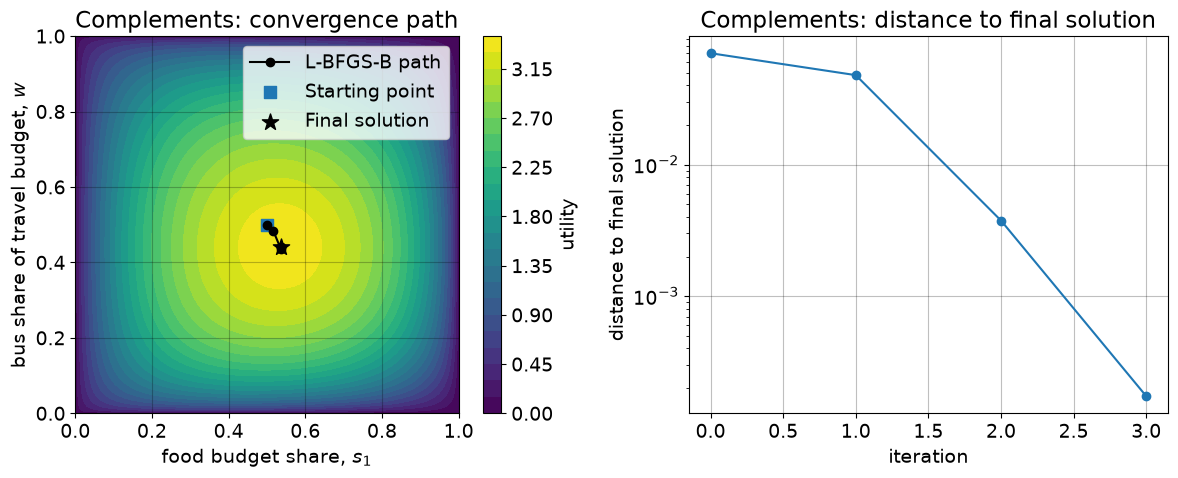

In [26]:
# I examine convergence for the complements calibration
convergence_complements = plot_convergence(
    model_complements,
    title='Complements'
)

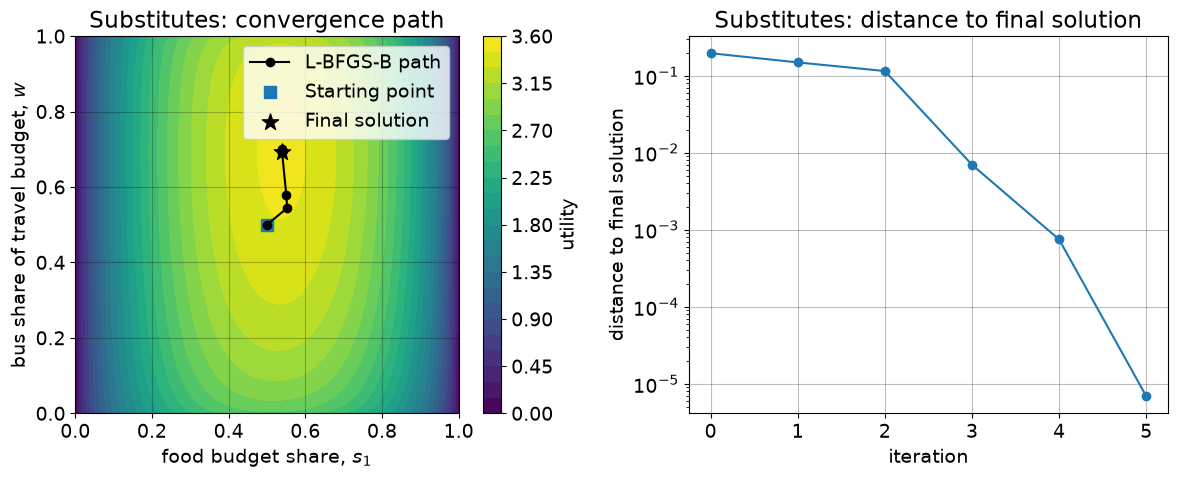

In [27]:
# I examine convergence for the substitutes calibration
convergence_substitutes = plot_convergence(
    model_substitutes,
    title='Substitutes'
)

I find that convergence is relatively slow in the first iterations, especially in the substitutes calibration. Once L-BFGS-B finds a useful search direction, the distance to the final solution decreases very rapidly.

The substitutes calibration requires more iterations and function evaluations than the complements calibration. This is consistent with the flatter utility surface in the $w$ direction: changes in $w$ generate relatively small changes in utility, which gives the optimizer less information about the direction of the optimum.

### 2.2.3 Different starting points

I now investigate whether the L-BFGS-B solution depends on the starting point. I use the middle of the unit square, all four corners and one additional interior starting point. I compare the final solution, utility, number of iterations and number of function evaluations.

In [28]:
# a. I define the starting points I want to investigate
starting_points = {
    'middle': np.array([0.50,0.50]),
    'corner (0,0)': np.array([0.00,0.00]),
    'corner (0,1)': np.array([0.00,1.00]),
    'corner (1,0)': np.array([1.00,0.00]),
    'corner (1,1)': np.array([1.00,1.00]),
    'interior (0.25,0.75)': np.array([0.25,0.75])
}


def compare_starting_points(model):
    """ I solve the model from several different starting points. """

    # b. I use the solution from the middle as my reference solution
    reference = model.solve(
        s0=np.array([0.5,0.5]),
        do_print=False
    )

    reference_solution = np.array([
        reference.s1,
        reference.w
    ])


    # c. I create an empty list for the results
    results = []


    # d. I solve the model from each starting point
    for name,s0 in starting_points.items():

        opt = model.solve(
            s0=s0,
            do_print=False
        )

        solution = np.array([
            opt.s1,
            opt.w
        ])


        # e. I calculate the distance to the reference solution
        distance = np.sqrt(
            np.sum(
                (solution-reference_solution)**2
            )
        )


        # f. I store the result
        results.append({
            'starting_point': name,
            'start_s1': s0[0],
            'start_w': s0[1],
            'final_s1': opt.s1,
            'final_w': opt.w,
            'utility': opt.u,
            'iterations': opt.res.nit,
            'function_evaluations': opt.res.nfev,
            'success': opt.res.success,
            'distance_to_reference': distance,
            'same_as_reference': distance < 1e-3
        })


    # g. I return all results as a table
    return pd.DataFrame(
        results
    )


# h. I run the experiment for the complements calibration
starts_complements = compare_starting_points(
    model_complements
)


# i. I run the experiment for the substitutes calibration
starts_substitutes = compare_starting_points(
    model_substitutes
)

In [29]:
# I display the starting-point results for the complements calibration
starts_complements.round(6)

,starting_point,start_s1,start_w,final_s1,final_w,utility,iterations,function_evaluations,success,distance_to_reference,same_as_reference
0,middle,0.50,0.50,0.535623,0.439479,3.40168,4,18,True,0.000000,True
1,"corner (0,0)",0.00,0.00,0.535624,0.439478,3.40168,7,27,True,0.000001,True
2,"corner (0,1)",0.00,1.00,0.535624,0.439478,3.40168,9,33,True,0.000001,True
3,"corner (1,0)",1.00,0.00,0.999991,0.000000,0.00000,1,21,True,0.639358,False
4,"corner (1,1)",1.00,1.00,0.999991,1.000000,0.00000,1,21,True,0.727888,False
5,"interior (0.25,0.75)",0.25,0.75,0.535624,0.439479,3.40168,6,24,True,0.000000,True


In [30]:
# I display the starting-point results for the substitutes calibration
starts_substitutes.round(6)

,starting_point,start_s1,start_w,final_s1,final_w,utility,iterations,function_evaluations,success,distance_to_reference,same_as_reference
0,middle,0.50,0.50,0.538225,0.692308,3.485105,6,27,True,0.000000,True
1,"corner (0,0)",0.00,0.00,0.538225,0.692305,3.485105,18,72,True,0.000003,True
2,"corner (0,1)",0.00,1.00,0.538225,0.692308,3.485105,17,66,True,0.000000,True
3,"corner (1,0)",1.00,0.00,0.538225,0.692308,3.485105,18,81,True,0.000000,True
4,"corner (1,1)",1.00,1.00,0.538225,0.692308,3.485105,16,66,True,0.000000,True
5,"interior (0.25,0.75)",0.25,0.75,0.538225,0.692307,3.485105,8,30,True,0.000000,True


The starting point affects both the number of iterations and the number of function evaluations. Most starting points converge to essentially the same optimum.

An important exception occurs in the complements calibration when I start at the all-food boundary, $s_1=1$. Both numerical corners $(1,0)$ and $(1,1)$ fail to reach the interior optimum and instead remain very close to $s_1=1$, with utility close to zero, even though L-BFGS-B reports `success = True`.

The two points represent the same economic allocation when $s_1=1$, because no income remains for travel and $w$ therefore has no effect on the actual budget shares. With bus and train as complements, moving away from this boundary can initially produce very little numerical improvement in utility, and the optimizer incorrectly interprets the local numerical gradient as evidence of convergence.

I therefore cannot rely on the `success` flag alone. I also compare the resulting utility and solution across starting points.

### 2.2.4 Solver tolerances

I investigate how the stopping tolerances affect the L-BFGS-B solution. I vary `ftol`, which controls when the objective stops changing sufficiently, and `gtol`, which controls when the gradient is sufficiently small.

I vary one setting at a time and report the optimal nested shares, utility and number of function evaluations for both calibrations.

In [31]:
# a. I choose the tolerance values specified in the assignment
ftol_values = [
    1e-4,
    1e-8,
    1e-12,
    1e-16
]

gtol_values = [
    1e-2,
    1e-5,
    1e-8,
    1e-12
]


def compare_tolerances(model):
    """ I compare different L-BFGS-B stopping tolerances. """

    results = []


    # b. I vary ftol while leaving the other settings at their defaults
    for ftol in ftol_values:

        opt = model.solve(
            do_print=False,
            options={
                'ftol': ftol
            }
        )

        results.append({
            'setting': 'ftol',
            'value': ftol,
            's1': opt.s1,
            'w': opt.w,
            'utility': opt.u,
            'function_evaluations': opt.res.nfev
        })


    # c. I vary gtol while leaving the other settings at their defaults
    for gtol in gtol_values:

        opt = model.solve(
            do_print=False,
            options={
                'gtol': gtol
            }
        )

        results.append({
            'setting': 'gtol',
            'value': gtol,
            's1': opt.s1,
            'w': opt.w,
            'utility': opt.u,
            'function_evaluations': opt.res.nfev
        })


    # d. I return the results as a table
    return pd.DataFrame(
        results
    )


# e. I compare tolerances for the complements calibration
tolerances_complements = compare_tolerances(
    model_complements
)


# f. I compare tolerances for the substitutes calibration
tolerances_substitutes = compare_tolerances(
    model_substitutes
)

In [32]:
# I display the tolerance results for the complements calibration
tolerances_complements

,setting,value,s1,w,utility,function_evaluations
0,ftol,1.000000e-04,0.535607,0.439652,3.40168,15
1,ftol,1.000000e-08,0.535623,0.439479,3.40168,18
2,ftol,1.000000e-12,0.535623,0.439479,3.40168,18
3,ftol,1.000000e-16,0.535623,0.439479,3.40168,18
4,gtol,1.000000e-02,0.535607,0.439652,3.40168,15
5,gtol,1.000000e-05,0.535623,0.439479,3.40168,18
6,gtol,1.000000e-08,0.535624,0.439478,3.40168,21
7,gtol,1.000000e-12,0.535624,0.439478,3.40168,21


In [33]:
# I display the tolerance results for the substitutes calibration
tolerances_substitutes

,setting,value,s1,w,utility,function_evaluations
0,ftol,1.000000e-04,0.538155,0.691562,3.485104,21
1,ftol,1.000000e-08,0.538225,0.692308,3.485105,27
2,ftol,1.000000e-12,0.538225,0.692308,3.485105,27
3,ftol,1.000000e-16,0.538225,0.692308,3.485105,27
4,gtol,1.000000e-02,0.538155,0.691562,3.485104,21
5,gtol,1.000000e-05,0.538225,0.692308,3.485105,27
6,gtol,1.000000e-08,0.538225,0.692308,3.485105,27
7,gtol,1.000000e-12,0.538225,0.692308,3.485105,27


### 2.2.5 Choice of solver settings

I prefer settings that give almost the highest obtainable utility without requiring unnecessary function evaluations. Based on the tolerance comparisons, I use `ftol=1e-8` and `gtol=1e-5`. These settings already produce a solution that is essentially unchanged when I tighten the tolerances further.

A tighter tolerance is not automatically better. The optimizer works with finite numerical precision and uses numerical approximations to the gradient. Once the solution is already extremely close to the optimum, tighter tolerances can require additional function evaluations without producing a meaningful improvement in utility. In some cases another stopping criterion can also become binding before the tighter tolerance matters.

In [34]:
# a. I define the solver settings I prefer
recommended_options = {
    'ftol': 1e-8,
    'gtol': 1e-5
}


# b. I solve the complements calibration using my preferred settings
final_complements = model_complements.solve(
    do_print=False,
    options=recommended_options
)


# c. I solve the substitutes calibration using the same settings
final_substitutes = model_substitutes.solve(
    do_print=False,
    options=recommended_options
)


# d. I collect the final solutions in a table
final_solver_table = pd.DataFrame([
    {
        'calibration': 'Complements',
        's1': final_complements.s1,
        'w': final_complements.w,
        'utility': final_complements.u,
        'function_evaluations': final_complements.res.nfev
    },
    {
        'calibration': 'Substitutes',
        's1': final_substitutes.s1,
        'w': final_substitutes.w,
        'utility': final_substitutes.u,
        'function_evaluations': final_substitutes.res.nfev
    }
])


# e. I display the final L-BFGS-B solutions
final_solver_table.round(6)

,calibration,s1,w,utility,function_evaluations
0,Complements,0.535623,0.439479,3.401680,18
1,Substitutes,0.538225,0.692308,3.485105,27


# 3. Relative prices and demand

I now use the model to examine how the consumer responds when train tickets become more expensive. I vary the train price $p_3$ from 0.5 to 3.0 while keeping $p_1$, $p_2$ and income $I$ fixed. I perform the analysis for both the complements and substitutes calibrations.

## 3.1 Budget shares and quantities

I first solve the model for train prices between $p_3=0.5$ and $p_3=3.0$. For each price, I record the three optimal budget shares and the three corresponding quantities. I do this for both calibrations and compare the results in the same figure.

In [35]:
def solve_price_path(sigma_B,p3_values):
    """ Solve the model for a sequence of train prices. """

    # a. I create a fresh model with the desired calibration
    model = ConsumerClass(
        par={'sigma_B': sigma_B}
    )

    # b. I create an empty list in which I store the results
    results = []

    # c. I solve the model for each train price
    for p3 in p3_values:

        # i. I change only the price of train tickets
        # I keep p1, p2 and income fixed
        model.par.p3 = p3

        # ii. I solve the consumer problem using my preferred
        # L-BFGS-B settings from Section 2
        opt = model.solve(
            do_print=False,
            options=recommended_options
        )

        # iii. I translate the optimal shares into quantities
        x1,x2,x3 = model.quantities(
            opt.s1,
            opt.w
        )

        # iv. I store the price, budget shares and quantities
        results.append({
            'p3': p3,
            's1': opt.s1,
            's2': opt.s2,
            's3': opt.s3,
            'x1': x1,
            'x2': x2,
            'x3': x3,
            'utility': opt.u
        })

    # d. I collect the results in a DataFrame
    return pd.DataFrame(
        results
    )


# e. I choose the train prices I want to examine
p3_values = np.linspace(
    0.5,
    3.0,
    101
)


# f. I solve the price experiment for the complements calibration
price_complements = solve_price_path(
    sigma_B=0.40,
    p3_values=p3_values
)


# g. I solve the same experiment for the substitutes calibration
price_substitutes = solve_price_path(
    sigma_B=3.00,
    p3_values=p3_values
)

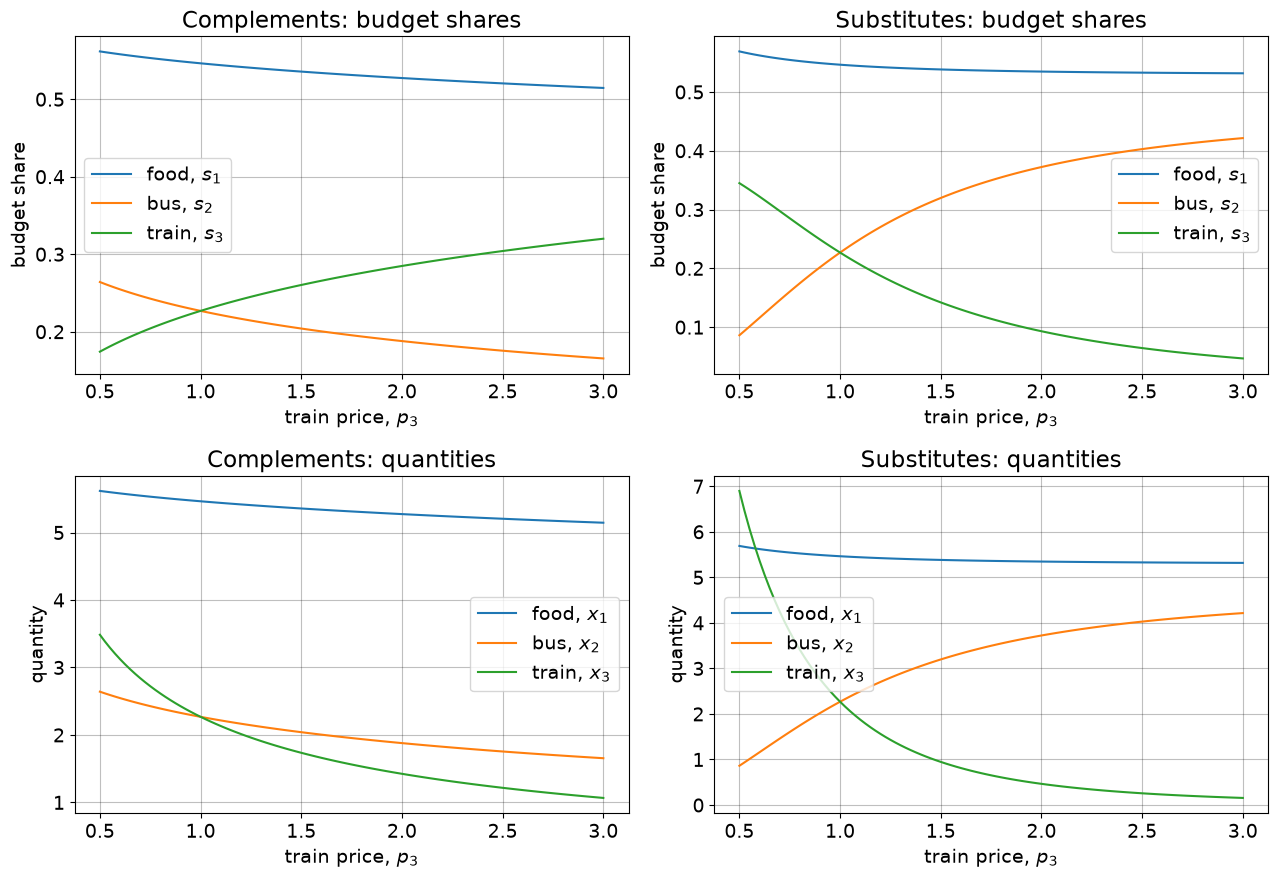

In [36]:
# a. I create one figure with four panels
fig = plt.figure(
    figsize=(13,9)
)


# b. I plot the budget shares for the complements calibration
ax = fig.add_subplot(
    2,
    2,
    1
)

ax.plot(
    price_complements['p3'],
    price_complements['s1'],
    label=r'food, $s_1$'
)

ax.plot(
    price_complements['p3'],
    price_complements['s2'],
    label=r'bus, $s_2$'
)

ax.plot(
    price_complements['p3'],
    price_complements['s3'],
    label=r'train, $s_3$'
)

ax.set_title(
    'Complements: budget shares'
)

ax.set_xlabel(
    r'train price, $p_3$'
)

ax.set_ylabel(
    'budget share'
)

ax.legend()


# c. I plot the budget shares for the substitutes calibration
ax = fig.add_subplot(
    2,
    2,
    2
)

ax.plot(
    price_substitutes['p3'],
    price_substitutes['s1'],
    label=r'food, $s_1$'
)

ax.plot(
    price_substitutes['p3'],
    price_substitutes['s2'],
    label=r'bus, $s_2$'
)

ax.plot(
    price_substitutes['p3'],
    price_substitutes['s3'],
    label=r'train, $s_3$'
)

ax.set_title(
    'Substitutes: budget shares'
)

ax.set_xlabel(
    r'train price, $p_3$'
)

ax.set_ylabel(
    'budget share'
)

ax.legend()


# d. I plot the quantities for the complements calibration
ax = fig.add_subplot(
    2,
    2,
    3
)

ax.plot(
    price_complements['p3'],
    price_complements['x1'],
    label=r'food, $x_1$'
)

ax.plot(
    price_complements['p3'],
    price_complements['x2'],
    label=r'bus, $x_2$'
)

ax.plot(
    price_complements['p3'],
    price_complements['x3'],
    label=r'train, $x_3$'
)

ax.set_title(
    'Complements: quantities'
)

ax.set_xlabel(
    r'train price, $p_3$'
)

ax.set_ylabel(
    'quantity'
)

ax.legend()


# e. I plot the quantities for the substitutes calibration
ax = fig.add_subplot(
    2,
    2,
    4
)

ax.plot(
    price_substitutes['p3'],
    price_substitutes['x1'],
    label=r'food, $x_1$'
)

ax.plot(
    price_substitutes['p3'],
    price_substitutes['x2'],
    label=r'bus, $x_2$'
)

ax.plot(
    price_substitutes['p3'],
    price_substitutes['x3'],
    label=r'train, $x_3$'
)

ax.set_title(
    'Substitutes: quantities'
)

ax.set_xlabel(
    r'train price, $p_3$'
)

ax.set_ylabel(
    'quantity'
)

ax.legend()


# f. I adjust the spacing between the four panels
fig.tight_layout()

## 3.2 Effect on the train budget share

I now examine how the budget share spent on train trips responds to a higher train price.

In [37]:
# a. I compare the train budget share at the lowest and highest train prices
train_share_table = pd.DataFrame([
    {
        'calibration': 'Complements',
        's3 at p3=0.5': price_complements.iloc[0]['s3'],
        's3 at p3=3.0': price_complements.iloc[-1]['s3'],
        'change in s3': (
            price_complements.iloc[-1]['s3']
            -
            price_complements.iloc[0]['s3']
        )
    },
    {
        'calibration': 'Substitutes',
        's3 at p3=0.5': price_substitutes.iloc[0]['s3'],
        's3 at p3=3.0': price_substitutes.iloc[-1]['s3'],
        'change in s3': (
            price_substitutes.iloc[-1]['s3']
            -
            price_substitutes.iloc[0]['s3']
        )
    }
])


# b. I display the comparison
train_share_table.round(6)

,calibration,s3 at p3=0.5,s3 at p3=3.0,change in s3
0,Complements,0.174241,0.319967,0.145726
1,Substitutes,0.344878,0.046830,-0.298048


In the complements calibration, I find that a higher train price increases the budget share spent on train trips. Although the consumer buys fewer train trips, train and bus are difficult to substitute for each other. The consumer therefore continues to devote a relatively large amount of expenditure to train travel even as the price rises.

In the substitutes calibration, I find the opposite result. The train budget share falls sharply when $p_3$ increases. Since bus and train are close substitutes, the consumer responds to the higher train price by shifting expenditure away from train trips and towards bus trips.

## 3.3 Effect on bus trips

I next examine how the number of bus trips changes when train tickets become more expensive. This comparison highlights the difference between complementarity and substitutability within the travel nest.

In [38]:
# a. I compare bus demand at the lowest and highest train prices
bus_demand_table = pd.DataFrame([
    {
        'calibration': 'Complements',
        'x2 at p3=0.5': price_complements.iloc[0]['x2'],
        'x2 at p3=3.0': price_complements.iloc[-1]['x2'],
        'change in x2': (
            price_complements.iloc[-1]['x2']
            -
            price_complements.iloc[0]['x2']
        )
    },
    {
        'calibration': 'Substitutes',
        'x2 at p3=0.5': price_substitutes.iloc[0]['x2'],
        'x2 at p3=3.0': price_substitutes.iloc[-1]['x2'],
        'change in x2': (
            price_substitutes.iloc[-1]['x2']
            -
            price_substitutes.iloc[0]['x2']
        )
    }
])


# b. I display the comparison
bus_demand_table.round(6)

,calibration,x2 at p3=0.5,x2 at p3=3.0,change in x2
0,Complements,2.640994,1.655132,-0.985862
1,Substitutes,0.862196,4.214712,3.352516


## 3.4 Effect on food demand

Finally, I examine how much the train price affects demand for food and compare this response with the change in bus demand. Since the train price changes inside the lower travel nest, I expect the strongest response to occur between bus and train rather than between travel and food.

In [39]:
# a. I calculate the changes in food and bus demand
food_bus_table = pd.DataFrame([
    {
        'calibration': 'Complements',
        'change in food x1': (
            price_complements.iloc[-1]['x1']
            -
            price_complements.iloc[0]['x1']
        ),
        'change in bus x2': (
            price_complements.iloc[-1]['x2']
            -
            price_complements.iloc[0]['x2']
        )
    },
    {
        'calibration': 'Substitutes',
        'change in food x1': (
            price_substitutes.iloc[-1]['x1']
            -
            price_substitutes.iloc[0]['x1']
        ),
        'change in bus x2': (
            price_substitutes.iloc[-1]['x2']
            -
            price_substitutes.iloc[0]['x2']
        )
    }
])


# b. I display the comparison
food_bus_table.round(6)

,calibration,change in food x1,change in bus x2
0,Complements,-0.471402,-0.985862
1,Substitutes,-0.372033,3.352516


I find that the train price has a relatively modest effect on food demand compared with its effect on bus demand.

In the complements calibration, food demand falls somewhat as train tickets become more expensive, but the decline in bus trips is larger. In the substitutes calibration, food demand again changes only moderately, while bus demand increases very strongly.

This difference reflects the nested preference structure. The price change occurs within the lower travel nest, so the strongest substitution response takes place between bus and train. Food belongs to the upper nest and is therefore less directly affected by the relative price change between the two travel goods.